*This optional notebook is in Spanish / Este cuaderno opcional está en español.*

# **Auto-Encoder y Auto-Encoder Variacional**

**Prerrequisitos:** nociones de CNNs y ciclos de entrenamiento (Sessions previas de la materia), y algo
de probabilidad básica (esperanza, distribuciones Gaussianas).

**Objetivos:** entender la diferencia entre un Auto-Encoder determinístico y uno Variacional (VAE),
implementar y entrenar ambos sobre MNIST, y entender el rol de la divergencia KL en el espacio latente
(y por qué, sin ella, samplear del espacio latente de un AE no funciona).

# Intro
Los VAEs son la versión variacional del AutoEncoder (AE).

Se entrenan de forma no supervisada, y lo que intentan es encontrar un código simple que represente los datos de entrada.

La idea principal es entrenar dos sub-redes que cooperan, un *encoder* que toma una imagen y la convierte en un código (usualmente de baja dimensión), y un *decoder* que toma ese código y lo vuelve a convertir en una imagen.

A este código se le suele llamar *código latente* o *variable latente*.


El AE no es generativo, y su espacio latente no es continuo. Samplear del espacio latente en general no lleva a buenos resultados, porque el espacio latente carece de estructura.

El VAE, en lugar de dejar libre al espacio latente, le impone restricciones.
En lugar de estimar directamente el código, se estiman los parámetros de una distribución. Luego, con la distribución caracterizada, es posible samplear de ese espacio y obtener datos válidos


Los VAEs son todas estas cosas al mismo tiempo


*   Deep neural networks
*   Bayesian statistical machines
*   Latent variable models
*   Maximum likelihood estimators
*   Dimensionality reducers
*   Generative models



# Ejemplos de uso

* **Reducción de dimension**: Al tener un código latente mucho más chico que la entrada, y lograr a la salida reconstruir la imagen original, estamos pasando todos los datos por un cuello de botella, lo cual implica que se debe condensar la información, descartando la menos importante.

* **Representation learning**: La idea por detrás de esto es lograr que las diferentes partes de nuestro código representen diferentes aspectos de nuestros datos. Con un poco de suerte podemos lograr que una dimensión de nuestro código latente represente por ejemplo si una persona está sonriendo o no, otra dimensión podría ser el color de pelo, y así...

# Auto-Encoder

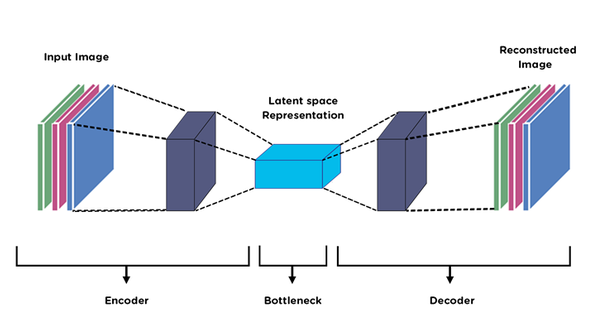

Dada una muestra $\mathbf x$, se le aplica el *encoder* $e(\mathbf{x})$ para obtener un código $\mathbf z$. Luego, se le aplica el *decoder* $d(\mathbf{z})$ y se obtiene la reconstrucción $\mathbf{\hat x}$.

Si el auto-encoder fuera perfecto, obtendríamos $\mathbf{\hat x} = \mathbf{x}$, o lo que es lo mismo $d(e(\mathbf{x})) = \hat{\mathbf{x}}$

Para entrenar un auto-encoder, lo que hacemos es minimizar la diferencia entre $\mathbf{ x}$ y $\mathbf{\hat x}$. Por ejemplo el **Mean Square Error (MSE)**:

$$\mathcal{L_R}=\frac{1}{N}\sum_{n=1}^N(x_n-\hat{x}_n)^2$$


## Código!

In [ ]:
import os
import torch
import numpy as np
from PIL import Image
from tqdm import tqdm
from torch import nn, optim
from IPython import display
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils

%matplotlib inline

# Seed for reproducibility
torch.manual_seed(0)


In [ ]:
class MnistTrainer:
    def __init__(self, model, learning_rate, epochs, subsample=False, checkpoint_name="last_weights.pth"):
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
        )
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.checkpoint_name = checkpoint_name
        self.model = model.to(self.device)
        self.optimizer = torch.optim.AdamW(
            self.model.parameters(), lr=self.learning_rate, betas=(0.9, 0.999), eps=1e-08
        )
        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.95)
        self.transform = transforms.Compose(
            [transforms.Resize(32), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])]
        )
        self.subsample = subsample

    def _load_state_checkpoint(self, checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location=self.device)
        print("Loading from checkpoint...")
        if "model_state_dict" in checkpoint:
            self.model.load_state_dict(checkpoint["model_state_dict"])
            print("\tweights")
        if "optimizer_state_dict" in checkpoint:
            self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            print("\toptimizer")
        return checkpoint

    def fit(self, training_dir, load_last_ckpt=False):

        dataset = datasets.MNIST("./data", transform=self.transform, download=True)
        if self.subsample:
            dataset = torch.utils.data.Subset(dataset, range(2000))
        loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=4)

        start_epoch = 0

        # Resume previous training (weights + optimizer only -- there is no validation set here,
        # so there is no best_val_loss to track/restore). Loaded once into `checkpoint`.
        checkpoint_path = os.path.join(training_dir, self.checkpoint_name)
        if os.path.exists(checkpoint_path) and load_last_ckpt:
            checkpoint = self._load_state_checkpoint(checkpoint_path)
            start_epoch = checkpoint.get("epoch", 0)

        train_num = len(loader)
        ite_num = start_epoch * train_num

        # Training loop
        # ---------------------------------------------------------------------------------------------------------------
        iterations = []
        train_loss = []
        for epoch in range(start_epoch, self.epochs):

            # Train step
            self.model.train()
            running_train_loss = 0.0
            epoch_loader = tqdm(loader)
            for i, (img, label) in enumerate(epoch_loader):
                ite_num += 1

                # Backprop
                self.model.zero_grad()
                self.optimizer.zero_grad()
                img = img.to(self.device)
                loss, out = self.model.compute_loss(img)
                loss.backward()
                self.optimizer.step()

                # Logs
                running_train_loss += loss.item()
                average_train_loss = running_train_loss / (i + 1)
                iterations.append(ite_num)
                train_loss.append(average_train_loss)
                epoch_loader.set_description(
                    "[Epoch: {:3d}/{:3d}][Batch: {:5d}/{:5d}][ite: {:d}] train loss: {:3f}".format(
                        epoch, self.epochs, (i + 1), train_num, ite_num, average_train_loss
                    )
                )

            self.scheduler.step()

            # Save models
            print("Saving last model")
            torch.save(
                {
                    "epoch": epoch + 1,
                    "model_state_dict": self.model.state_dict(),
                    "optimizer_state_dict": self.optimizer.state_dict(),
                },
                os.path.join(training_dir, self.checkpoint_name),
            )

            # Show some images. No clear_output(): every epoch's sample grid stays in the output,
            # and the loss plot always redraws from the full `iterations`/`train_loss` history, so
            # nothing is lost across epochs.
            display_freq = 1
            if epoch % display_freq == 0:

                sample_size = min(img.shape[0], 10)
                sample = img[:sample_size]

                self.model.eval()
                with torch.no_grad():
                    out, _ = self.model(sample)

                utils.save_image(
                    torch.cat([sample, out], 0),
                    os.path.join(training_dir, "sample.png"),
                    nrow=sample_size,
                    normalize=True,
                    value_range=(-1, 1),
                )

                display.display(display.Image(os.path.join(training_dir, "sample.png"), width=720))
                plt.figure()
                plt.plot(iterations, train_loss)
                plt.title("Train Loss")
                plt.show()
                print(
                    "[Epoch: {:3d}/{:3d}][Batch: {:5d}/{:5d}][ite: {:d}] train loss: {:3f}\n\n".format(
                        epoch, self.epochs, (i + 1), train_num, ite_num, average_train_loss
                    )
                )

### Encoder / Decoder

In [ ]:
# Residual Block
# ------------------------------------------------------------------------------
class ResidualSubNet(nn.Module):
    def __init__(self, in_out_channels, mid_channels):
        super().__init__()

        self.blocks = nn.Sequential(
            nn.ReLU(inplace=True),
            nn.Conv2d(in_out_channels, mid_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channels, in_out_channels, kernel_size=1)
        )

    def forward(self, input):
        out = self.blocks(input)
        out += input
        return out

# Encoder
# ------------------------------------------------------------------------------
class Encoder(nn.Module):
    def __init__(self, input_dim=3, latent_dim=64, middle_dim=32, residual_dim=32):
        super().__init__()

        blocks = [
            nn.Conv2d(input_dim, middle_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(middle_dim, latent_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(latent_dim, latent_dim, kernel_size=3, padding=1),
            ResidualSubNet(latent_dim, residual_dim),
            ResidualSubNet(latent_dim, residual_dim),
            nn.ReLU(inplace=True),
            nn.Conv2d(latent_dim, middle_dim, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(middle_dim, latent_dim, kernel_size=3, padding=1),
            ResidualSubNet(latent_dim, residual_dim),
            ResidualSubNet(latent_dim, residual_dim),
            nn.ReLU(inplace=True),
        ]

        self.blocks = nn.Sequential(*blocks)

    def forward(self, input):
        return self.blocks(input)

# Decoder
# ------------------------------------------------------------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim=64, middle_dim=128, out_dim=3, residual_dim=32):
        super().__init__()

        blocks = [
            nn.Conv2d(latent_dim, middle_dim, kernel_size=3, padding=1),
            ResidualSubNet(middle_dim, residual_dim),
            ResidualSubNet(middle_dim, residual_dim),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(middle_dim, latent_dim, kernel_size=4, stride=2, padding=1),
            nn.Conv2d(latent_dim, middle_dim, kernel_size=3, padding=1),
            ResidualSubNet(middle_dim, residual_dim),
            ResidualSubNet(middle_dim, residual_dim),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(middle_dim, middle_dim // 2, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(middle_dim // 2, out_dim, kernel_size=4, stride=2, padding=1),
        ]

        self.blocks = nn.Sequential(*blocks)
        # No output activation here (e.g. Tanh): inputs are normalized to [-1, 1]
        # (see transforms.Normalize([0.5], [0.5]) in MnistTrainer), so the decoder
        # must learn to produce that range unconstrained.

    def forward(self, input):
        return self.blocks(input)

### Auto-Encoder!

In [ ]:
class AE(nn.Module):
    def __init__(self, img_channels):
        super().__init__()
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
        )
        self.encoder = Encoder(input_dim=img_channels, latent_dim=64)
        self.decoder = Decoder(out_dim=img_channels, latent_dim=64)
        self.loss = nn.MSELoss()

    def forward(self, input):
        enc = self.encoder(input)
        dec = self.decoder(enc)
        return dec, []

    def compute_loss(self, img):
        out, _ = self(img)
        return self.loss(out, img), out  # (input, target)

### Train Auto-Encoder

In [ ]:
ae = AE(img_channels=1)

trainer = MnistTrainer(ae, learning_rate=1e-4, epochs=20, subsample=True, checkpoint_name="ae_weights.pth")
trainer.fit(training_dir='.', load_last_ckpt=False)

### Comentarios finales

1. Se obtienen reconstrucciones bastante buenas, aunque algo borrosas. Probablemente esto mejore entrenando más y/o un modelo más grande, o agrandando la dimensión del espacio latente. Pero siempre habrá algo de pérdida, desde el momento que el código latente tenga mucho menos dimensión que la entrada. Lo cual no siempre es malo --> Denoising por ejemplo...

    Los Auto-Encoders pueden verse como una forma no-lineal de **PCA**. De hecho, se puede probar que un Auto-Encoder con una sola capa en el *encoder* y una sola en el *decoder* y ciertos pesos, es exactamente **PCA**.

2. No es posible generar muestras nuevas. No es un modelo generativo. Simplemente es un modelo que comprime la entrada y la reconstruye lo mejor que puede. Si corremos el *decoder* sobre una entrada random, no podemos esperar que reconstruya nada parecido.



In [ ]:
ae.eval()
with torch.no_grad():
    out = ae.decoder(torch.rand(1, 64, 4, 4).to(ae.device))

plt.imshow(out[0, 0, :, :].detach().cpu().numpy())
plt.axis("off")

# Auto-Encoder Variacional (VAE)



En este caso ya no utilizaremos el error cuadrático medio para la función de pérdida, porque en lugar de simplemente reconstruir la imagen, lo que queremos hacer es generar nuevas!

Ahora vamos a deducirla, pero nuestra nueva loss se llama **ELBO** y tiene 2 términos:

* Término de reconstrucción, que hace el mismo trabajo que el **MSE** en el **AE**
* Término de **Divergencia Kullback-Leibler**, que hará que el **VAE** aprenda la distribución de los datos


## Divergencia Kullback-Leibler

Un **poco de Teoría de Información**:

Siendo $P$ y $Q$ dos distribuciones:

* La información que aporta el evento $x$ respecto a la probabilidad $P$ es $I_P(x) = -\log P(x)$
* De forma similar, la información respecto a la probabilidad $Q$ es $I_Q(x) = -\log Q(x)$

Por tanto la diferencia de información es $$\Delta I = I_Q - I_P = \log P(x) - \log Q(x) = \log \frac{P(x)}{Q(x)} $$

**La divergencia Kullback-Leibler es la esperanza de dicha magnitud**

\begin{equation}
D_{KL}(P||Q) := E_{x\sim P} [\Delta I] = \sum_x P(x)\log\frac{P(x)}{Q(x)}
\end{equation}

Es una medida de similitud (o divergencia) entre distribuciones de probabilidad.

No es simétrica, es decir $D_{KL}(P||Q) \neq D_{KL}(Q||P)$.


## Extra: Jensen-Shannon Divergence

No se usa para el VAE, pero ya que estamos...

Es otra medida de similitud, basada en KLD.

Es simétrica.

\begin{equation}
 D_{JS}(P||Q) = \frac{1}{2}D_{KL}(P,M) + \frac{1}{2}D_{KL}(Q,M)
\end{equation}

Siendo $M = \frac{P + Q}{2}$ el promedio de $P$ y $Q$, y $D_{KL}$ la divergencia Kullback-Leibler.

## VAE Loss

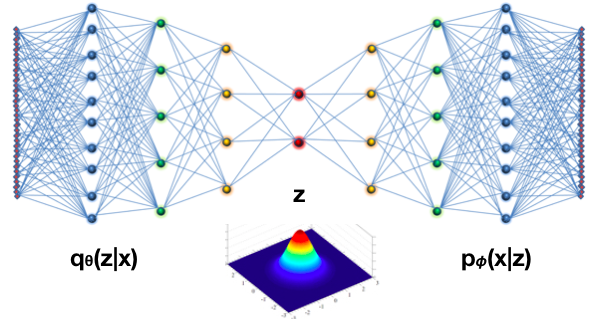

Los modelos discriminativos aprenden $p(y | x)$

Los modelos generativos aprenden diferentes cosas acerca de $p(x)$. Por ejemplo:

* GANs aprenden a muestrear de $p(x)$.
* VAEs aprenden a aproximar $p(x)$.
* Conditional VAEs aprenden a aproximar $p(x|y)$.
* Normalizing flows aprenden $p(x)$
* Modelos Auto-regresivos aprenden $p(x_i|x_{i-1},x_{i-2},...,x_1)$.

Empezamos planteando la divergencia entre las probabilidades en el medio, de las dos partes de la red:

$$ D_{KL}(q_\theta(z|x) || p(z|x)) = - \sum_z q_\theta (z|x) \log \frac{p(z|x)}{q_\theta (z|x)}$$

Y aplicando **Bayes**:

$$ = - \sum_z q_\theta (z|x) \log \frac{p_\phi(x|z)p(z)}{q_\theta (z|x)p(x)}$$

Aplicando algunas leyes de logaritmo, viendo que $p(x)$ no juega en la suma en $z$, que la suma $\sum_z q_\theta (z|x)$ vale 1, porque es una distribución de probabilidad, batiendo y con un soplido:

$$ = - \sum_z q_\theta (z|x) \log \frac{p_\phi (x|z)p(z)}{q_\theta (z|x)} + \log p(x)$$

Operando un poquito más:

$$ = - \sum_z q_\theta (z|x) \log \frac{p(z)}{q_\theta (z|x)} - \sum_z q_\theta (z|x) \log  p_\phi (x|z) + \log p(x)$$

Y finalmente:

$$ D_{KL}(q_\theta(z|x) || p(z|x)) = D_{KL}(q_\theta(z|x) || p(z)) - E_{q_\theta (z|x)}[\log p_\phi (x|z)] + \log p(x)$$





Bueno, lo de arriba es una divergencia, así que es mayor a cero, lo cual implica que:

.

\begin{equation}
    \boxed{
    \log p(x) \geq - D_{KL}(q_\theta(z|x) || p(z)) + E_{q_\theta (z|x)}[\log p_\phi (x|z)]}
\end{equation}

.

$p(x)$ es la evidencia, también llamada *marginal likelihood*, fácil de ver cuando marginalizamos $p(x) = \sum_z p(x|z) p(z)$.

La *marginal likelihood* nos dice qué tan bien nuestros datos se ajustan a nuestro modelo.

Dicho de otra forma, nos dice qué tan bueno es nuestro modelo basado en la evidencia de los datos.

**Cuanto más alta es la evidencia (o la *marginal likelihood*), mejor es nuestro modelo!**

Entonces lo que queremos hacer es maximizar $p(x)$, lo cual es idéntico a maximizar $\log p(x)$ porque $\log$ es monótona creciente.

$\log p(x)$ no se puede calcular así nomás, porque hay que sumar en todo $\mathcal{Z}$, y eso es **infeasible** .

Entonces, como siempre en optimización, lo que hacemos es maximizar una cota inferior, y eso es justo lo que tenemos acá! a la derecha de la ecuación, la cual le llamamos **Evidence Lower Bound (ELBO)**


### ELBO

Es la cota inferior de la evidencia (la fórmula de la celda anterior).

Es lo que vamos a **maximizar**.

Nuestra **Loss** es simplemente el negativo del ELBO (los optimizadores minimizan, así que minimizar
$-\text{ELBO}$ es lo mismo que maximizar el ELBO):

\begin{equation}
    \boxed{
    \mathcal{L}(\theta, \phi) = -\text{ELBO} = D_{KL}(q_\theta(z|x) || p(z)) - E_{q_\theta (z|x)}[\log p_\phi (x|z)]}
\end{equation}

El primer término es una especie de regularizador, porque impone restricciones en la forma en la que
aproximamos nuestro posterior. El segundo (con su signo negativo) es un término de reconstrucción,
porque minimizarlo equivale a maximizar el *likelihood* de la reconstrucción.

La otra buena noticia es que son todas cosas calculables, si elegimos bien!

Acá es cuando todo se pone Gaussiano... en algún momento tenía que pasar...

Si elegimos $p(z)$ y $q_\theta (z|x)$ sean gaussianos, el término de la divergencia tiene forma
cerrada, y es (créanme):

$$ D_{KL} = -\frac{1}{2} \sum \left[ 1 + \log (\sigma^2) - \sigma^2 - \mu^2 \right] $$

y eso es lo que utilizaremos para la función de loss!

**De la teoría al código:** en la práctica no calculamos $E_{q_\theta(z|x)}[\log p_\phi(x|z)]$ de forma
exacta. Si asumimos que el decoder modela $p_\phi(x|z)$ como una Gaussiana de varianza fija centrada en
la reconstrucción $\hat x$, entonces $-\log p_\phi(x|z) \propto \text{MSE}(x, \hat x) + \text{cte}$. Por
eso en el código de más abajo usamos `nn.MSELoss()` como término de reconstrucción: es la forma práctica
de aproximar (menos) esa esperanza.

## Por fin el código...

In [ ]:
class VAE(nn.Module):
    def __init__(self, img_channels, encoder_latent_dim=64, latent_dim=128, kld_weight=0.1):
        super().__init__()
        input_size = 32
        self.smallest_size = input_size // (2**3)
        self.encoder_latent_dim = encoder_latent_dim
        self.latent_dim = latent_dim
        self.device = torch.device(
            "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
        )

        self.encoder = Encoder(input_dim=img_channels, latent_dim=encoder_latent_dim)
        self.enc_fc = nn.Linear(self.smallest_size * self.smallest_size * encoder_latent_dim, 2 * latent_dim)

        self.dec_fc = nn.Linear(latent_dim, self.smallest_size * self.smallest_size * encoder_latent_dim)
        # latent_dim must match encoder_latent_dim (the decoder's input channels); pass explicitly
        # rather than relying on Decoder's own default happening to agree.
        # No output activation (e.g. Tanh) here either -- see the note in the Decoder class;
        # inputs are normalized to [-1, 1].
        self.decoder = Decoder(out_dim=img_channels, latent_dim=encoder_latent_dim)

        self.mse = nn.MSELoss()
        self.kld_weight = kld_weight

    def reparameterize(self, mu, l_var):
        std = torch.exp(0.5 * l_var)
        eps = torch.randn_like(std)
        return eps * std + mu

    def forward(self, input):
        # Encode
        x = self.encoder(input)
        x = x.view(x.size(0), -1)
        x = self.enc_fc(x)
        [mu, lvar] = torch.chunk(x, 2, dim=1)

        # Generate sample from our estimated distribution
        z = self.reparameterize(mu, lvar)

        # Decode
        z = self.dec_fc(z)
        z = z.view(-1, self.encoder_latent_dim, self.smallest_size, self.smallest_size)
        dec = self.decoder(z)

        return dec, [mu, lvar]

    def compute_loss(self, img):
        out, [mu, l_var] = self(img)
        recons_loss = self.mse(out, img)  # (input, target) -- consistent with AE.compute_loss
        kld_loss = torch.mean(-0.5 * torch.sum(1 + l_var - mu**2 - l_var.exp(), dim=1), dim=0)
        loss = recons_loss + self.kld_weight * kld_loss
        return loss, out

**¿Por qué `kld_weight` es tan chico (0.01)?** `nn.MSELoss()` promedia el error sobre **todos** los
píxeles (reconstrucción ≈ media por píxel), mientras que `kld_loss` se calcula como una **suma** sobre
las dimensiones del espacio latente (128 en este caso) y luego se promedia sobre el batch. Sin
re-escalar, el término KL dominaría la loss total y el modelo colapsaría el posterior hacia el prior
("posterior collapse"), ignorando la reconstrucción. Bajar `kld_weight` compensa ese desbalance de
escalas -- esta es exactamente la idea detrás de **β-VAE** (Higgins et al., 2017), que introduce un peso
$\beta$ ajustable sobre el término KL.

*Nota de runtime: 40 épocas (reducido de 200 por el presupuesto de tiempo de clase) -- alcanza para
ver generación y reconstrucción razonables en unos pocos minutos en CPU/MPS.*

In [ ]:
vae = VAE(img_channels=1, latent_dim=128, kld_weight=0.01)

trainer = MnistTrainer(vae, learning_rate=3e-4, epochs=40, subsample=True, checkpoint_name="vae_weights.pth")
trainer.fit(training_dir='.', load_last_ckpt=False)

Una vez entrenada nuestra red, veamos la diferencia entre la generación
* Sampleando del prior $p(z)$
* Sampleando del posterior aproximado $q_\theta(z|x)$

In [ ]:
n_samples = 10
noise = torch.normal(0, 1, size=(n_samples, vae.latent_dim)).to(vae.device)

# Data
dataset = datasets.MNIST("./data", transform=trainer.transform, download=True)
loader = DataLoader(dataset, batch_size=n_samples, shuffle=True, num_workers=0)
data = next(iter(loader))[0]

vae.eval()
with torch.no_grad():
    # Sample from prior
    x = vae.dec_fc(noise)
    x = x.view(-1, vae.encoder_latent_dim, vae.smallest_size, vae.smallest_size)
    prior_dec = vae.decoder(x)

    # Sample from posterior
    posterior_dec, [mu, lvar] = vae(data.to(vae.device))

# Plot
all_data = torch.cat([d for d in data[:, 0, :, :]], dim=1).to(vae.device)
all_prior_dec = torch.cat([d for d in prior_dec[:, 0, :, :]], dim=1)
all_posterior_dec = torch.cat([d for d in posterior_dec[:, 0, :, :]], dim=1)
comparison_grid = torch.cat([all_prior_dec, all_data, all_posterior_dec], dim=0)

plt.figure(figsize=(15, 15))
plt.imshow(comparison_grid.detach().cpu().numpy(), cmap="gray")
plt.axis("off")

### Qué pasa si interpolamos entre 2 códigos latentes?

In [ ]:
idx1 = 7
idx2 = 9

vae.eval()
with torch.no_grad():
    z = vae.reparameterize(mu, lvar)
    z1 = z[idx1]
    z2 = z[idx2]

    alpha = 0.75
    zmerge = alpha * z1 + (1 - alpha) * z2
    z = vae.dec_fc(zmerge)
    z = z.view(-1, vae.encoder_latent_dim, vae.smallest_size, vae.smallest_size)
    dec = vae.decoder(z)

plt.imshow(dec[0, 0, :, :].detach().cpu().numpy(), cmap="gray")
plt.axis("off")

### Generando distintas realizaciones (Parte generativa!)

In [ ]:
generated_samples = []
vae.eval()
with torch.no_grad():
    for i in range(10):
        z = vae.reparameterize(mu, lvar)[idx2]
        z = vae.dec_fc(z)
        z = z.view(-1, vae.encoder_latent_dim, vae.smallest_size, vae.smallest_size)
        generated_samples.append(vae.decoder(z))

all_samples = torch.cat([d[0, 0, :, :] for d in generated_samples], dim=1)

plt.figure(figsize=(15, 15))
plt.imshow(all_samples.detach().cpu().numpy(), cmap="gray")
plt.axis("off")

# Fin!